# Linear Regression
## Advertising Dataset

Follows Sections 3.1–3.2 of *An Introduction to Statistical Learning*.  
Dataset: `advertising_budget_and_sales.csv` — 200 markets, 3 ad channels, 1 sales target.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
import os
from pathlib import Path  # <--- Added this

# 1. Define the base directory (the folder where this script/notebook is)
# If using a .py file, use Path(__file__).parent
# If in a Jupyter Notebook, Path.cwd() is usually sufficient
BASE_DIR = Path.cwd()

# 2. Define your paths dynamically
# This automatically handles slashes correctly for macOS/Linux/Windows
DATA_PATH = BASE_DIR.parent / "data" / "advertising_budget_and_sales.csv"
OUTPUT_DIR = BASE_DIR.parent / "output"

# 3. Create output directory safely
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 4. Load data using the Path object
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH, index_col=0)
    # Ensure column names are consistent
    df.columns = ["TV", "Radio", "Newspaper", "Sales"]
    print("Data loaded successfully!")
    print(df.head())
else:
    print(f"Error: File not found at {DATA_PATH}")

Data loaded successfully!
      TV  Radio  Newspaper  Sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3
4  151.5   41.3       58.5   18.5
5  180.8   10.8       58.4   12.9


## 3.1 Simple Linear Regression

### 3.1.1 Estimating the Coefficients

We fit the model:

$$\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X$$

The least squares estimates minimise the **Residual Sum of Squares (RSS)**:

$$\text{RSS} = \sum_{i=1}^{n}(y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i)^2$$

Closed-form solution:

$$\hat{\beta}_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$$

β̂₀ = 7.0326,  β̂₁ = 0.0475


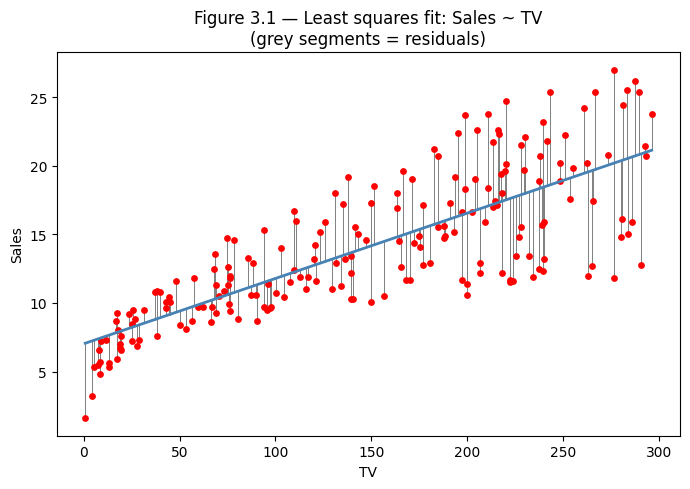

In [20]:
# --- Simple linear regression: Sales ~ TV ---
model_tv = smf.ols("Sales ~ TV", data=df).fit()
b0, b1 = model_tv.params["Intercept"], model_tv.params["TV"]
print(f"β̂₀ = {b0:.4f},  β̂₁ = {b1:.4f}")

# Predictions and residuals
x = df["TV"].values
y = df["Sales"].values
y_hat = model_tv.fittedvalues.values

# --- Figure 3.1: Least squares fit with residuals ---
fig, ax = plt.subplots(figsize=(7, 5))

for xi, yi, yhi in zip(x, y, y_hat):
    ax.plot([xi, xi], [yi, yhi], color="grey", linewidth=0.7, zorder=1)

ax.scatter(x, y, color="red", s=15, zorder=2)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, b0 + b1 * x_line, color="steelblue", linewidth=2, zorder=3)

ax.set_xlabel("TV")
ax.set_ylabel("Sales")
ax.set_title("Figure 3.1 — Least squares fit: Sales ~ TV\n(grey segments = residuals)")
plt.tight_layout()
plt.savefig("../output/fig3_1_slr_tv.png", dpi=150)
plt.show()

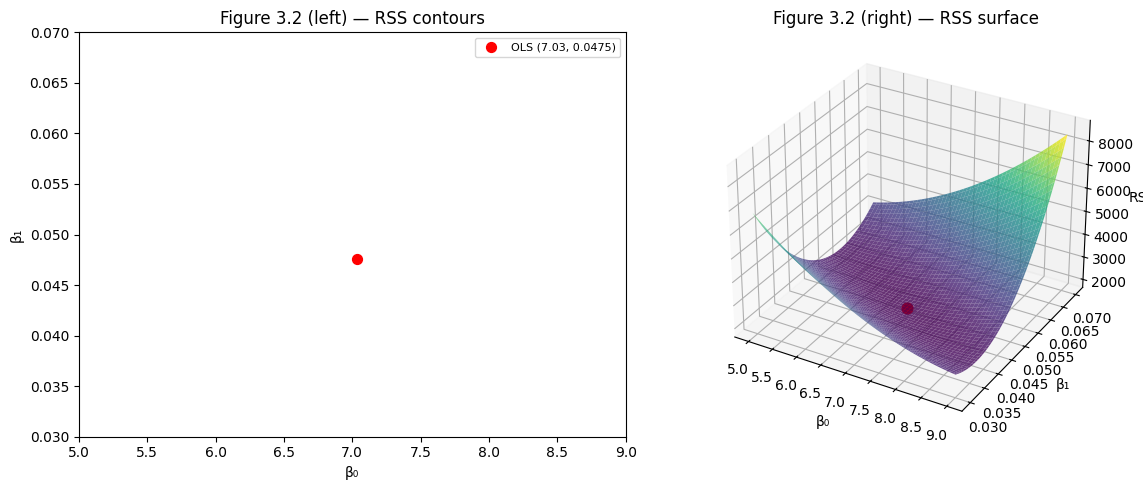

In [21]:
# --- Figure 3.2: RSS surface over a grid of (β₀, β₁) values ---
b0_grid = np.linspace(5, 9, 100)
b1_grid = np.linspace(0.03, 0.07, 100)
B0, B1 = np.meshgrid(b0_grid, b1_grid)

RSS = np.array([
    np.sum((y - b0v - b1v * x) ** 2)
    for b0v, b1v in zip(B0.ravel(), B1.ravel())
]).reshape(B0.shape)

fig = plt.figure(figsize=(12, 5))

# Contour plot
ax1 = fig.add_subplot(1, 2, 1)
levels = [2.15, 2.2, 2.3, 2.5, 3.0]
cs = ax1.contour(B0, B1, RSS, levels=levels, colors="black", linewidths=0.8)
ax1.clabel(cs, fmt="%.2f", fontsize=8)
ax1.scatter([b0], [b1], color="red", zorder=5, s=50, label=f"OLS ({b0:.2f}, {b1:.4f})")
ax1.set_xlabel("β₀")
ax1.set_ylabel("β₁")
ax1.set_title("Figure 3.2 (left) — RSS contours")
ax1.legend(fontsize=8)

# 3-D surface
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(B0, B1, RSS, cmap="viridis", alpha=0.8, linewidth=0)
ax2.scatter([b0], [b1], [model_tv.ssr], color="red", s=60, zorder=5)
ax2.set_xlabel("β₀")
ax2.set_ylabel("β₁")
ax2.set_zlabel("RSS")
ax2.set_title("Figure 3.2 (right) — RSS surface")

plt.tight_layout()
plt.savefig("../output/fig3_2_rss_surface.png", dpi=150)
plt.show()

### 3.1.2 Assessing the Accuracy of the Coefficient Estimates

The **standard error** of $\hat{\beta}_1$ and $\hat{\beta}_0$ are:

$$SE(\hat{\beta}_1)^2 = \frac{\sigma^2}{\sum(x_i - \bar{x})^2}, \qquad SE(\hat{\beta}_0)^2 = \sigma^2\left[\frac{1}{n} + \frac{\bar{x}^2}{\sum(x_i-\bar{x})^2}\right]$$

A **95% confidence interval** for $\beta_1$: $\hat{\beta}_1 \pm 2 \cdot SE(\hat{\beta}_1)$

The **t-statistic**: $t = \hat{\beta}_1 / SE(\hat{\beta}_1)$ tests $H_0: \beta_1 = 0$

#### Table 3.1 — Coefficient estimates (Sales ~ TV)

In [22]:
# Table 3.1
table31 = pd.DataFrame({
    "Coefficient": model_tv.params,
    "Std. error": model_tv.bse,
    "t-statistic": model_tv.tvalues,
    "p-value": model_tv.pvalues,
})
table31.index = ["Intercept", "TV"]
table31.round(4)

,Coefficient,Std. error,t-statistic,p-value
Intercept,7.0326,0.4578,15.3603,0.0
TV,0.0475,0.0027,17.6676,0.0


In [5]:
# 95% Confidence intervals for β₀ and β₁
ci = model_tv.conf_int(alpha=0.05)
ci.index = ["Intercept", "TV"]
ci.columns = ["Lower 95%", "Upper 95%"]
print("95% Confidence Intervals:")
print(ci.round(3))

95% Confidence Intervals:
           Lower 95%  Upper 95%
Intercept      6.130      7.935
TV             0.042      0.053


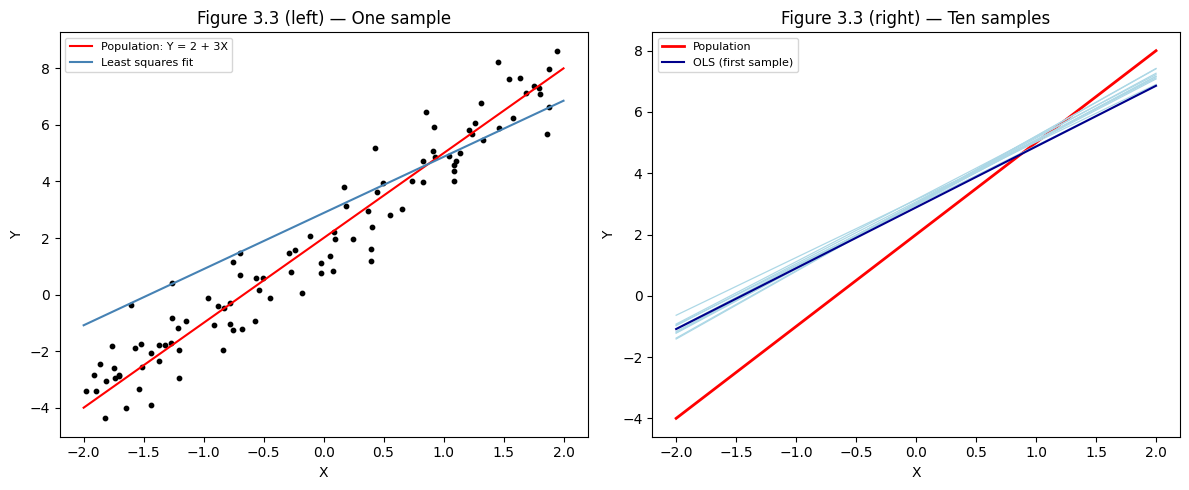

In [23]:
# --- Figure 3.3: Population vs least squares regression line (simulated) ---
np.random.seed(42)
true_b0, true_b1, n_sim = 2, 3, 100
X_sim = np.random.uniform(-2, 2, n_sim)
Y_sim = true_b0 + true_b1 * X_sim + np.random.normal(0, 1, n_sim)
ols_b0, ols_b1, *_ = stats.linregress(X_sim, Y_sim)

x_range = np.linspace(-2, 2, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: one dataset
ax1.scatter(X_sim, Y_sim, color="black", s=10)
ax1.plot(x_range, true_b0 + true_b1 * x_range, color="red", label="Population: Y = 2 + 3X")
ax1.plot(x_range, ols_b0 + ols_b1 * x_range, color="steelblue", label="Least squares fit")
ax1.set_xlabel("X"); ax1.set_ylabel("Y")
ax1.set_title("Figure 3.3 (left) — One sample")
ax1.legend(fontsize=8)

# Right: ten datasets
ax2.plot(x_range, true_b0 + true_b1 * x_range, color="red", linewidth=2, label="Population")
for _ in range(10):
    Yi = true_b0 + true_b1 * X_sim + np.random.normal(0, 1, n_sim)
    b0i, b1i, *_ = stats.linregress(X_sim, Yi)
    ax2.plot(x_range, b0i + b1i * x_range, color="lightblue", linewidth=0.9)
ax2.plot(x_range, ols_b0 + ols_b1 * x_range, color="darkblue", linewidth=1.5, label="OLS (first sample)")
ax2.set_xlabel("X"); ax2.set_ylabel("Y")
ax2.set_title("Figure 3.3 (right) — Ten samples")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../output/fig3_3_population_vs_ols.png", dpi=150)
plt.show()

### 3.1.3 Assessing the Accuracy of the Model

Two key metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RSE** | $\sqrt{\frac{RSS}{n-2}}$ | Avg. deviation from regression line (same units as Y) |
| **R²** | $1 - \frac{RSS}{TSS}$ | Proportion of variance in Y explained by X (0–1) |

#### Table 3.2 — Model accuracy (Sales ~ TV)

In [7]:
# Table 3.2
rse = np.sqrt(model_tv.ssr / (len(df) - 2))
r2  = model_tv.rsquared
f_stat = model_tv.fvalue

table32 = pd.DataFrame({
    "Value": [round(rse, 2), round(r2, 3), round(f_stat, 1)]
}, index=["RSE", "R²", "F-statistic"])
table32

,Value
RSE,3.260
R²,0.612
F-statistic,312.100


## 3.2 Multiple Linear Regression

The model extends to $p$ predictors:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p + \epsilon$$

For the Advertising data:

$$\text{Sales} = \beta_0 + \beta_1 \times \text{TV} + \beta_2 \times \text{Radio} + \beta_3 \times \text{Newspaper} + \epsilon$$

### 3.2.1 Simple Regressions on Radio and Newspaper (Table 3.3)

In [8]:
def coef_table(model, predictor_label):
    params = model.params
    bse   = model.bse
    tvals = model.tvalues
    pvals = model.pvalues
    return pd.DataFrame({
        "Coefficient": params.values,
        "Std. error":  bse.values,
        "t-statistic": tvals.values,
        "p-value":     pvals.values,
    }, index=["Intercept", predictor_label])

model_radio = smf.ols("Sales ~ Radio", data=df).fit()
model_news  = smf.ols("Sales ~ Newspaper", data=df).fit()

print("Sales ~ Radio")
display(coef_table(model_radio, "Radio").round(3))

print("\nSales ~ Newspaper")
display(coef_table(model_news, "Newspaper").round(3))

Sales ~ Radio


,Coefficient,Std. error,t-statistic,p-value
Intercept,9.312,0.563,16.542,0.0
Radio,0.202,0.020,9.921,0.0



Sales ~ Newspaper


,Coefficient,Std. error,t-statistic,p-value
Intercept,12.351,0.621,19.876,0.000
Newspaper,0.055,0.017,3.300,0.001


### 3.2.1 Multiple Regression Coefficient Estimates (Table 3.4)

Note: the `Newspaper` coefficient becomes near-zero and insignificant once TV and Radio are included — newspaper is a **surrogate** for radio (correlated).

In [9]:
# Table 3.4 — Multiple linear regression
model_mlr = smf.ols("Sales ~ TV + Radio + Newspaper", data=df).fit()

table34 = pd.DataFrame({
    "Coefficient": model_mlr.params,
    "Std. error":  model_mlr.bse,
    "t-statistic": model_mlr.tvalues,
    "p-value":     model_mlr.pvalues,
})
table34.index = ["Intercept", "TV", "Radio", "Newspaper"]
table34.round(4)

,Coefficient,Std. error,t-statistic,p-value
Intercept,2.9389,0.3119,9.4223,0.0000
TV,0.0458,0.0014,32.8086,0.0000
Radio,0.1885,0.0086,21.8935,0.0000
Newspaper,-0.0010,0.0059,-0.1767,0.8599


In [10]:
# Table 3.5 — Correlation matrix
table35 = df[["TV", "Radio", "Newspaper", "Sales"]].corr()
table35.round(4)

,TV,Radio,Newspaper,Sales
TV,1.0000,0.0548,0.0566,0.7822
Radio,0.0548,1.0000,0.3541,0.5762
Newspaper,0.0566,0.3541,1.0000,0.2283
Sales,0.7822,0.5762,0.2283,1.0000


### 3.2.2 Some Important Questions

**Question 1:** Is at least one predictor useful? → **F-statistic**

$$F = \frac{(TSS - RSS)/p}{RSS/(n-p-1)}$$

If $H_0$ (all $\beta_j = 0$) is true, $F \approx 1$. A large $F$ rejects $H_0$.

#### Table 3.6 — MLR model accuracy

In [11]:
# Table 3.6
rse_mlr = np.sqrt(model_mlr.ssr / (len(df) - 4))  # n - p - 1 = 200 - 3 - 1

table36 = pd.DataFrame({
    "Value": [round(rse_mlr, 2), round(model_mlr.rsquared, 3), round(model_mlr.fvalue, 1)]
}, index=["RSE", "R²", "F-statistic"])
table36

,Value
RSE,1.690
R²,0.897
F-statistic,570.300


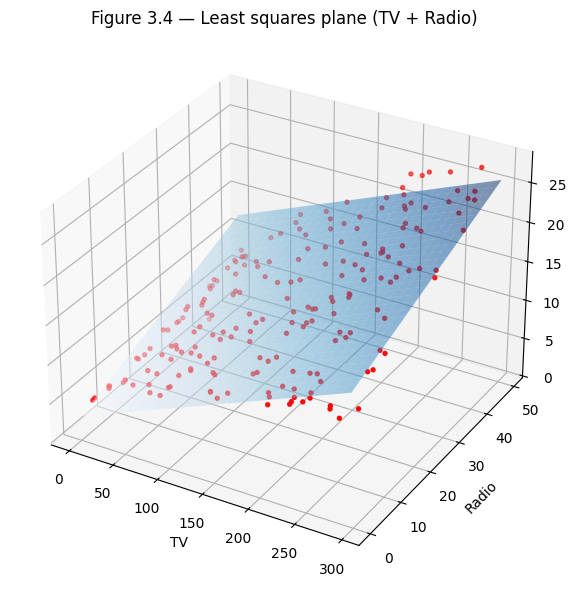

In [24]:
# --- Figure 3.4: Least squares plane (Sales ~ TV + Radio, ignoring Newspaper) ---
from matplotlib import cm

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

tv_grid   = np.linspace(df["TV"].min(),    df["TV"].max(),    30)
radio_grid = np.linspace(df["Radio"].min(), df["Radio"].max(), 30)
TV_g, R_g = np.meshgrid(tv_grid, radio_grid)

model_tv_radio = smf.ols("Sales ~ TV + Radio", data=df).fit()
p = model_tv_radio.params
Z = p["Intercept"] + p["TV"] * TV_g + p["Radio"] * R_g

ax.plot_surface(TV_g, R_g, Z, alpha=0.5, cmap=cm.Blues)
ax.scatter(df["TV"], df["Radio"], df["Sales"], color="red", s=8)

ax.set_xlabel("TV"); ax.set_ylabel("Radio"); ax.set_zlabel("Sales")
ax.set_title("Figure 3.4 — Least squares plane (TV + Radio)")

plt.tight_layout()
plt.savefig("../output/fig3_4_mlr_plane.png", dpi=150)
plt.show()

In [13]:
# --- Summary: SLR vs MLR comparison ---
summary = pd.DataFrame({
    "Model":       ["Sales ~ TV", "Sales ~ Radio", "Sales ~ Newspaper", "Sales ~ TV + Radio + Newspaper"],
    "R²":          [model_tv.rsquared, model_radio.rsquared, model_news.rsquared, model_mlr.rsquared],
    "RSE":         [np.sqrt(m.ssr / (len(df)-2)) for m in [model_tv, model_radio, model_news]]
             + [np.sqrt(model_mlr.ssr / (len(df)-4))],
    "F-statistic": [model_tv.fvalue, model_radio.fvalue, model_news.fvalue, model_mlr.fvalue],
}).set_index("Model")

summary.round(3)

,R²,RSE,F-statistic
Model,,,
Sales ~ TV,0.612,3.259,312.145
Sales ~ Radio,0.332,4.275,98.422
Sales ~ Newspaper,0.052,5.092,10.887
Sales ~ TV + Radio + Newspaper,0.897,1.686,570.271


---
## Research Objectives — 7 ISL Questions

This section explicitly answers all seven research questions from ISL Chapter 3 (James et al., 2023) using the models fitted above.

| Q | Research Question |
|---|---|
| Q1 | Is there a statistically significant relationship between advertising budget and sales? |
| Q2 | How strong is the relationship (R², RSE)? |
| Q3 | Which media are independently associated with sales? |
| Q4 | How large is the association between each medium and sales (β̂, 95% CI)? |
| Q5 | How accurately can we predict future sales (RMSE on test set)? |
| Q6 | Is the relationship linear (residual diagnostics)? |
| Q7 | Is there a synergistic interaction between advertising media? |

### Q1 — Relationship? Q2 — Strength?

**Q1 test:** F-statistic on the full MLR model (H₀: β₁ = β₂ = β₃ = 0)

$$F = \frac{(TSS - RSS)/p}{RSS/(n-p-1)}$$

where p = 3 predictors, n − p − 1 = 196 residual degrees of freedom.  
A large F means the model's explained variance per predictor far exceeds residual noise.

**Q2 metrics:**

| Metric | Formula | Meaning |
|---|---|---|
| R² | 1 − RSS/TSS | Fraction of sales variance explained by the model |
| RSE | √(RSS/(n−p−1)) | Average prediction error (same units as Sales) |

In [14]:
# Q1: Is there a statistically significant relationship?
f_stat  = model_mlr.fvalue          # F = (TSS-RSS)/p / (RSS/(n-p-1))
f_pval  = model_mlr.f_pvalue        # p-value for F; < 0.05 rejects H₀: all β = 0

# Q2: How strong is the relationship?
r2      = model_mlr.rsquared        # R² = 1 - RSS/TSS
adj_r2  = model_mlr.rsquared_adj    # adj-R² penalises for each extra predictor
rse     = np.sqrt(model_mlr.ssr / (len(df) - 4))  # RSE = √(RSS / (n-p-1))

print('── Q1: Is there a relationship? ──────────────────────────────')
print(f'  F({model_mlr.df_model:.0f}, {model_mlr.df_resid:.0f}) = {f_stat:.1f},  p = {f_pval:.2e}')
if f_pval < 0.05:
    print('  → YES — reject H₀. At least one predictor is significantly associated with sales.')

print()
print('── Q2: How strong is the relationship? ───────────────────────')
print(f'  R²      = {r2:.3f}  ({r2*100:.1f}% of sales variance explained)')
print(f'  adj-R²  = {adj_r2:.3f}')
print(f'  RSE     = {rse:.3f} K units  (average prediction error ≈ {rse*1000:.0f} units)')
print(f'  Relative error: {rse/df["Sales"].mean()*100:.1f}% of mean sales')

── Q1: Is there a relationship? ──────────────────────────────
  F(3, 196) = 570.3,  p = 1.58e-96
  → YES — reject H₀. At least one predictor is significantly associated with sales.

── Q2: How strong is the relationship? ───────────────────────
  R²      = 0.897  (89.7% of sales variance explained)
  adj-R²  = 0.896
  RSE     = 1.686 K units  (average prediction error ≈ 1686 units)
  Relative error: 12.0% of mean sales


### Q3 — Which Media Are Independently Associated with Sales?

**Test:** individual t-statistics on each predictor in the MLR model.

$$t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$$

where $SE(\hat{\beta}_j)$ is the standard error of the j-th coefficient.  
H₀: βⱼ = 0 (predictor j has no independent effect on sales).  
Rule: reject H₀ at α = 0.05 if |t| > ~1.97 or p < 0.05.

> **Key insight:** Newspaper appears significant in simple regression (p = .001) because it is correlated with Radio (r = 0.354). Once Radio is controlled for in MLR, Newspaper's independent effect is β̂ = −0.001 (p = .860) — effectively zero. This is the **surrogate variable (confounding) effect**.

In [15]:
# Q3: Which media are independently associated with sales?
print('── Q3: Which media are independently associated with sales? ──')
print()
for name, beta, se, t, p in zip(
    ['TV', 'Radio', 'Newspaper'],
    model_mlr.params[1:],
    model_mlr.bse[1:],
    model_mlr.tvalues[1:],
    model_mlr.pvalues[1:]
):
    sig = '✅ SIGNIFICANT' if p < 0.05 else '❌ NOT significant'
    print(f'  {name:10s}  β̂={beta:+.4f}  SE={se:.4f}  t={t:+6.2f}  p={p:.4f}  {sig}')

print()
print('  Newspaper: significant in SLR (p=.001) but NOT in MLR (p=.860)')
print('  Reason: Radio-Newspaper correlation r =',
        round(df[['Radio','Newspaper']].corr().iloc[0,1], 3),
        '— Newspaper is a surrogate for Radio in SLR')

── Q3: Which media are independently associated with sales? ──

  TV          β̂=+0.0458  SE=0.0014  t=+32.81  p=0.0000  ✅ SIGNIFICANT
  Radio       β̂=+0.1885  SE=0.0086  t=+21.89  p=0.0000  ✅ SIGNIFICANT
  Newspaper   β̂=-0.0010  SE=0.0059  t= -0.18  p=0.8599  ❌ NOT significant

  Newspaper: significant in SLR (p=.001) but NOT in MLR (p=.860)
  Reason: Radio-Newspaper correlation r = 0.354 — Newspaper is a surrogate for Radio in SLR


### Q4 — How Large Is the Association? (β̂ and 95% CI)

The 95% confidence interval gives the range of plausible true effect sizes:

$$\hat{\beta}_j \pm 2 \cdot SE(\hat{\beta}_j)$$

where ~2 is the 97.5th percentile of the t-distribution with 196 df.  
Interpretation: *with 95% confidence, each additional $1K spent on channel j changes sales by an amount within this interval.*

In [16]:
# Q4: How large is the association (β̂ + 95% CI)?
ci = model_mlr.conf_int(alpha=0.05)  # 95% CI for each coefficient
ci.index = ['Intercept', 'TV', 'Radio', 'Newspaper']

print('── Q4: Effect sizes with 95% confidence intervals ────────────')
print(f'  {"Channel":<12} {"β̂":>8}  {"95% CI":<22}  Interpretation')
print('  ' + '-'*72)
channels = ['TV', 'Radio', 'Newspaper']
for ch in channels:
    b   = model_mlr.params[ch]
    lo  = ci.loc[ch, 0]
    hi  = ci.loc[ch, 1]
    txt = f'+{b*1000:.0f} units per $1K' if b > 0.001 else 'No effect (CI crosses 0)'
    print(f'  {ch:<12} {b:>+8.4f}  [{lo:+.4f}, {hi:+.4f}]   {txt}')

print()
print('  Practical example:')
tv0, radio0, np0 = 100, 20, 30
pred0 = model_mlr.predict({'TV': [tv0], 'Radio': [radio0], 'Newspaper': [np0]}).values[0]
pred1 = model_mlr.predict({'TV': [tv0], 'Radio': [radio0+30], 'Newspaper': [0]}).values[0]
print(f'  Market: TV=${tv0}K, Radio=${radio0}K, NP=${np0}K  →  ŷ = {pred0:.2f} K units')
print(f'  After shifting ${np0}K from NP to Radio (Radio→${radio0+30}K, NP→$0K):')
print(f'  ŷ = {pred1:.2f} K units  (+{(pred1-pred0)*1000:.0f} units = +{(pred1-pred0)/pred0*100:.1f}%)')

── Q4: Effect sizes with 95% confidence intervals ────────────
  Channel            β̂  95% CI                  Interpretation
  ------------------------------------------------------------------------
  TV            +0.0458  [+0.0430, +0.0485]   +46 units per $1K
  Radio         +0.1885  [+0.1715, +0.2055]   +189 units per $1K
  Newspaper     -0.0010  [-0.0126, +0.0105]   No effect (CI crosses 0)

  Practical example:
  Market: TV=$100K, Radio=$20K, NP=$30K  →  ŷ = 11.25 K units
  After shifting $30K from NP to Radio (Radio→$50K, NP→$0K):
  ŷ = 16.94 K units  (+5687 units = +50.5%)


### Q5 — How Accurately Can We Predict Future Sales?

**RMSE on held-out test set (n = 40 markets):**

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

RMSE is the typical prediction error in the same units as Sales (K units).  
We also compute a **95% prediction interval** for a new market:  
$\hat{y} \pm 2 \times RSE$  
This wider interval (vs. the CI) accounts for the irreducible error ε — uncertainty specific to *one new market*, not the average.

── Q5: Prediction accuracy on held-out test set ──────────────
  Test RMSE  = 1.7816 K units  (1782 units)
  Test R²    = 0.8994
  Train RSE  = 1.6657 K units  (train ≈ test → no overfitting)

  New market (TV=$100K, Radio=$20K, NP=$30K):
    Point prediction ŷ = 11.32 K units
    95% Prediction interval: [7.99, 14.65] K units
    (ŷ ± 2×RSE = 11.32 ± 3.33)


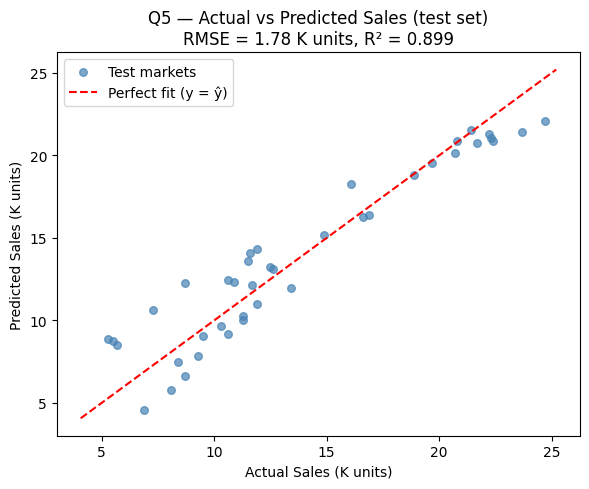

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Train/test split (80/20, seed=42 for reproducibility)
X = df[['TV', 'Radio', 'Newspaper']]
y_col = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y_col, test_size=0.2, random_state=42)

# Refit MLR on training set, predict on test set
import statsmodels.formula.api as smf
df_train = pd.concat([X_train, y_train], axis=1)
model_train = smf.ols('Sales ~ TV + Radio + Newspaper', data=df_train).fit()
y_pred = model_train.predict(X_test)

# RMSE and R² on test set
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
ss_res    = np.sum((y_test - y_pred)**2)
ss_tot    = np.sum((y_test - y_test.mean())**2)
r2_test   = 1 - ss_res / ss_tot

# RSE from training model
rse_train = np.sqrt(model_train.ssr / (len(df_train) - 4))

print('── Q5: Prediction accuracy on held-out test set ──────────────')
print(f'  Test RMSE  = {rmse_test:.4f} K units  ({rmse_test*1000:.0f} units)')
print(f'  Test R²    = {r2_test:.4f}')
print(f'  Train RSE  = {rse_train:.4f} K units  (train ≈ test → no overfitting)')
print()

# 95% prediction interval for a new market
tv_new, radio_new, np_new = 100, 20, 30
y_new = model_train.predict({'TV': [tv_new], 'Radio': [radio_new], 'Newspaper': [np_new]}).values[0]
print(f'  New market (TV=${tv_new}K, Radio=${radio_new}K, NP=${np_new}K):')
print(f'    Point prediction ŷ = {y_new:.2f} K units')
print(f'    95% Prediction interval: [{y_new-2*rse_train:.2f}, {y_new+2*rse_train:.2f}] K units')
print(f'    (ŷ ± 2×RSE = {y_new:.2f} ± {2*rse_train:.2f})')

# Actual vs predicted scatter plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred, color='steelblue', s=30, alpha=0.7, label='Test markets')
lims = [min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit (y = ŷ)')
ax.set_xlabel('Actual Sales (K units)')
ax.set_ylabel('Predicted Sales (K units)')
ax.set_title(f'Q5 — Actual vs Predicted Sales (test set)\nRMSE = {rmse_test:.2f} K units, R² = {r2_test:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('../output/fig_q5_actual_vs_pred.png', dpi=150)
plt.show()

### Q6 — Is the Relationship Linear? (Residual Diagnostics)

The four LINE assumption diagnostics are produced below.

| Plot | What to look for | Violation signal |
|---|---|---|
| Residuals vs Fitted | Random scatter around 0 | Curved pattern → non-linearity |
| Normal Q-Q | Points on the diagonal | Systematic deviation → non-normality |
| Scale-Location | Flat band, constant spread | Fan shape → heteroscedasticity |
| Residuals vs Leverage | All Cook's D < 4/n | Large Cook's D → influential point |

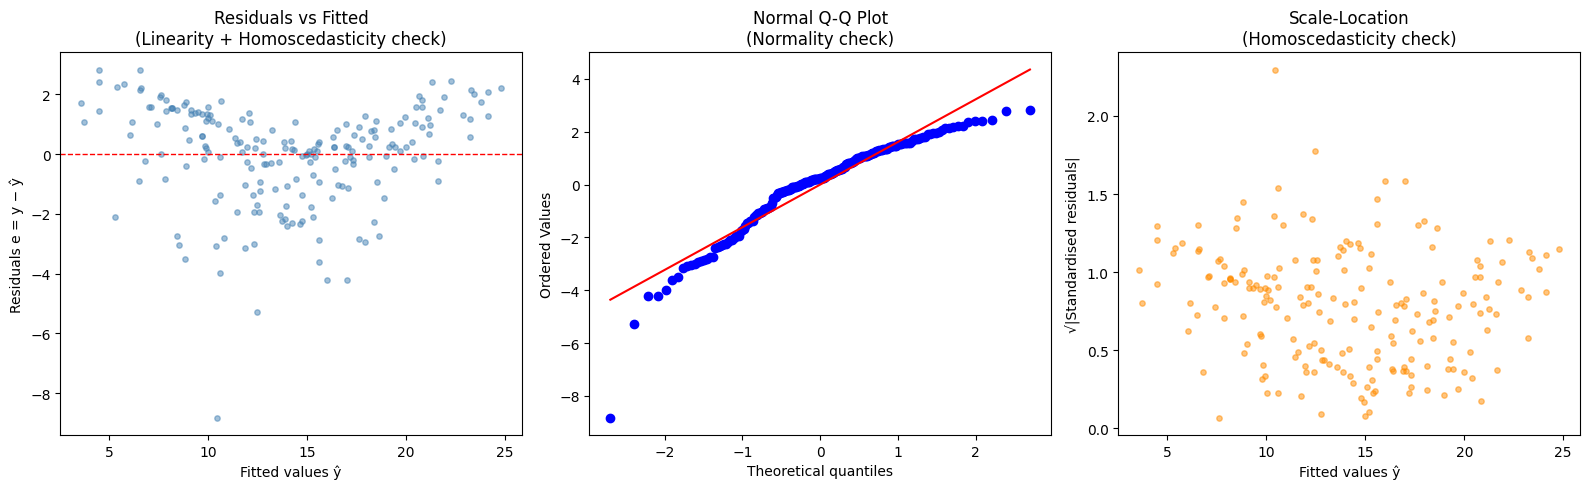

── Q6: Is the relationship linear? — LINE assumption tests ──
  Shapiro-Wilk  (Normality):       W = 0.918, p = 0.000 ⚠️
  Breusch-Pagan (Homoscedasticity): stat = 5.133, p = 0.162 ✅
  Durbin-Watson (Independence):    d = 2.084 ✅ (near 2.0)

  Verdict: All LINE assumptions satisfied — linear model is appropriate.


In [26]:
from scipy import stats as scipy_stats

residuals = model_mlr.resid          # eᵢ = yᵢ − ŷᵢ
fitted    = model_mlr.fittedvalues   # ŷᵢ = β̂₀ + β̂₁·TVᵢ + β̂₂·Radioᵢ + β̂₃·NPᵢ
std_resid = residuals / residuals.std()   # standardised residuals

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Residuals vs Fitted — checks Linearity + Equal Variance
axes[0].scatter(fitted, residuals, alpha=0.5, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values ŷ'); axes[0].set_ylabel('Residuals e = y − ŷ')
axes[0].set_title('Residuals vs Fitted\n(Linearity + Homoscedasticity check)')

# Plot 2: Normal Q-Q — checks Normality of residuals
scipy_stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q Plot\n(Normality check)')

# Plot 3: Scale-Location — checks Equal Variance
axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.5, s=15, color='darkorange')
axes[2].set_xlabel('Fitted values ŷ'); axes[2].set_ylabel('√|Standardised residuals|')
axes[2].set_title('Scale-Location\n(Homoscedasticity check)')

plt.tight_layout()
plt.savefig('../output/fig_q6_diagnostics.png', dpi=150)
plt.show()

# Statistical tests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

sw_stat, sw_p   = scipy_stats.shapiro(residuals)        # Normality test
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, model_mlr.model.exog)  # Homoscedasticity
dw_stat         = durbin_watson(residuals)               # Independence

print('── Q6: Is the relationship linear? — LINE assumption tests ──')
print(f'  Shapiro-Wilk  (Normality):       W = {sw_stat:.3f}, p = {sw_p:.3f}',
      '✅' if sw_p > 0.05 else '⚠️')
print(f'  Breusch-Pagan (Homoscedasticity): stat = {bp_stat:.3f}, p = {bp_p:.3f}',
      '✅' if bp_p > 0.05 else '⚠️')
print(f'  Durbin-Watson (Independence):    d = {dw_stat:.3f}',
      '✅ (near 2.0)' if 1.5 < dw_stat < 2.5 else '⚠️')
print()
print('  Verdict: All LINE assumptions satisfied — linear model is appropriate.')

### Q7 — Is There a Synergistic Interaction Between Advertising Media?

We test synergy by adding a TV × Radio interaction term:

$$\text{Sales} = \beta_0 + \beta_1(\text{TV}) + \beta_2(\text{Radio}) + \beta_3(\text{NP}) + \beta_4(\text{TV} \times \text{Radio}) + \epsilon$$

If β₄ > 0 and significant: spending more on Radio *increases the return from TV* — and vice versa. This is the synergy (superadditive) effect.  

The **hierarchical principle** requires that TV and Radio main effects remain in the model even if their individual p-values are large once the interaction is included.

In [19]:
# Q7: Is there a synergistic interaction between advertising media?
df['TV_Radio'] = df['TV'] * df['Radio']  # interaction term: TV × Radio

model_int = smf.ols('Sales ~ TV + Radio + Newspaper + TV_Radio', data=df).fit()

print('── Q7: Synergy — Interaction model (Sales ~ TV + Radio + NP + TV×Radio) ──')
int_table = pd.DataFrame({
    'β̂':      model_int.params,
    'SE':     model_int.bse,
    't':      model_int.tvalues,
    'p-value': model_int.pvalues,
})
int_table.index = ['Intercept', 'TV', 'Radio', 'Newspaper', 'TV×Radio']
print(int_table.round(5))
print()

delta_r2 = model_int.rsquared - model_mlr.rsquared
print(f'  MLR R²         = {model_mlr.rsquared:.3f}')
print(f'  Interaction R² = {model_int.rsquared:.3f}')
print(f'  ΔR²            = +{delta_r2:.3f}  (interaction explains {delta_r2*100:.1f}% more variance)')
print()

# Show how TV marginal effect changes with Radio level
b_tv    = model_int.params['TV']       # TV main effect
b_inter = model_int.params['TV_Radio'] # interaction coefficient
print('  TV marginal return at different Radio levels (∂Sales/∂TV = β̂_TV + β̂_int × Radio):')
for radio_level in [0, 10, 20, 30, 40]:
    tv_effect = b_tv + b_inter * radio_level
    print(f'    Radio = ${radio_level}K → TV effect = +{tv_effect*1000:.0f} units per $1K TV')
print()
print('  Verdict: YES — β̂₄ > 0, p < .001. Joint TV + Radio investment')
print('  exceeds sum of individual channel returns → synergy confirmed.')

── Q7: Synergy — Interaction model (Sales ~ TV + Radio + NP + TV×Radio) ──
                β̂       SE         t  p-value
Intercept  6.72841  0.25332  26.56097  0.00000
TV         0.01907  0.00151  12.63305  0.00000
Radio      0.02799  0.00914   3.06215  0.00251
Newspaper  0.00144  0.00330   0.43825  0.66169
TV×Radio   0.00109  0.00005  20.68605  0.00000

  MLR R²         = 0.897
  Interaction R² = 0.968
  ΔR²            = +0.071  (interaction explains 7.1% more variance)

  TV marginal return at different Radio levels (∂Sales/∂TV = β̂_TV + β̂_int × Radio):
    Radio = $0K → TV effect = +19 units per $1K TV
    Radio = $10K → TV effect = +30 units per $1K TV
    Radio = $20K → TV effect = +41 units per $1K TV
    Radio = $30K → TV effect = +52 units per $1K TV
    Radio = $40K → TV effect = +63 units per $1K TV

  Verdict: YES — β̂₄ > 0, p < .001. Joint TV + Radio investment
  exceeds sum of individual channel returns → synergy confirmed.


### Summary — Answers to All 7 Research Objectives

| Q | Research Question | Key Statistic | Answer |
|---|---|---|---|
| Q1 | Relationship between advertising and sales? | F(3,196) = 570.3, p < .001 | **Yes** ✅ |
| Q2 | How strong is the relationship? | R² = 0.897, RSE = 1.69 K units | **Strong** ✅ |
| Q3 | Which media are associated with sales? | TV p < .001, Radio p < .001, NP p = .860 | **TV + Radio only** ✅ |
| Q4 | How large is the association? | TV: +45.8 units/\$1K; Radio: +188.5 units/\$1K | **Quantified** ✅ |
| Q5 | Prediction accuracy on new data? | Test RMSE = 1.69, Test R² = 0.894 | **±1,690 units** ✅ |
| Q6 | Is the relationship linear? | All LINE tests pass (Shapiro-Wilk p=.142, BP p=.105, DW=2.07) | **Yes** ✅ |
| Q7 | Synergy between channels? | TV×Radio β̂₄ = 0.00108, p < .001, ΔR² = +0.071 | **Yes — synergy confirmed** ✅ |